# Calculation of empirical p-values and FDRs for LFC values

- Redo counts normalization
    - RPM (reads per million) with pseudo-count of 1
- Calculate LFC for each replicate relative to median “input” gRNA RPM 
- Generate empirical null distribution by combining all replicates of non- and safe-targeting gRNAs in each condition


    - Bootstrap to generate a sufficiently large null distribution



- Calculate empirical p-value (low and high) based on null distribution
    - P(high) = (S+1)/(N+1), where s = # of null values GREATER than gRNA of interest
    - P(low) = same, but s = # of null values LESS than gRNA of interest
- Combine p-values using Fisher’s method
- Perform FDR correction using Benjamini-Hochberg method

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

# MAGeCK example

Example of taking the counts files and making them useable for MAGeCK. We want a table that has columns of samples and rows of guide counts. This came from the pre_and_post processing notebook from Sam's BE sensor pipeline and I'm just using it to generate the counts file. This counts file contains both the puro and noPuro samples since they're all in the same folder...I'll see how critical this in in downstream analysis because it's not as easy to make separate files right now unless I separate the puro vs nonpuro samples into separate folders which could cause some problems with the code I've already written in terms of location and such. Otherwise I have to write the function so that the dictionary isn't just sequentially assigned but is based off specific file matching I give it. But i think since the columns are clearly lnoPuroled in the mageck output it will be fine to subset what I want

In [17]:
config_df = pd.read_csv('/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San/sensor_extraction_fastq_split_config_HC_DASIT.txt', sep=' ')


sample_id = ["D0_preEPO_rep1",
    "D0_preEPO_rep2",
    "D0_preEPO_rep3",
    "D3_rep2",
    "D3_rep3",
    "D5_noPuro_rep1",
    "D5_noPuro_rep2",
    "D5_noPuro_rep3",
    "D5_puro_rep1",
    "D5_puro_rep2",
    "D5_puro_rep3",
    "D15_noPuro_rep1",
    "D15_noPuro_rep2",
    "D15_noPuro_rep3",
    "D15_puro_rep1",
    "D15_puro_rep2",
    "D15_puro_rep3"]

samp = [i for i in config_df['folder_name']]

samp_dict = dict(zip(samp, sample_id))
samp_dict

{'D25-251027_guide_split_BARCODES': 'D0_preEPO_rep1',
 'D25-251028_guide_split_BARCODES': 'D0_preEPO_rep2',
 'D25-251029_guide_split_BARCODES': 'D0_preEPO_rep3',
 'D25-251030_guide_split_BARCODES': 'D3_rep2',
 'D25-251031_guide_split_BARCODES': 'D3_rep3',
 'D25-251032_guide_split_BARCODES': 'D5_noPuro_rep1',
 'D25-251033_guide_split_BARCODES': 'D5_noPuro_rep2',
 'D25-251034_guide_split_BARCODES': 'D5_noPuro_rep3',
 'D25-251035_guide_split_BARCODES': 'D5_puro_rep1',
 'D25-251036_guide_split_BARCODES': 'D5_puro_rep2',
 'D25-251037_guide_split_BARCODES': 'D5_puro_rep3',
 'D25-251038_guide_split_BARCODES': 'D15_noPuro_rep1',
 'D25-251039_guide_split_BARCODES': 'D15_noPuro_rep2',
 'D25-251040_guide_split_BARCODES': 'D15_noPuro_rep3',
 'D25-251041_guide_split_BARCODES': 'D15_puro_rep1',
 'D25-251042_guide_split_BARCODES': 'D15_puro_rep2',
 'D25-251043_guide_split_BARCODES': 'D15_puro_rep3'}

In [18]:
#-------UPDATE THESE 2 PARAMTERS----
fp = '/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San/counts'
chosen_count_column = 'bc_count' #can also choose "matched_guide_count" or "total_guide_count"

df_holder = []
s_name = []
for i, k in enumerate(samp):
    aa = pd.read_csv(f'{fp}/{k}_count_df.csv')
    aa = aa[['Guide_ID', chosen_count_column]]

    s = samp_dict[k]

    aa = aa.rename(columns = {chosen_count_column:f'{s}'})

    if i>0:
        aa = aa.rename(columns = {'Guide_ID':'Guide_ID_x'})
    df_holder.append(aa)

join_out = pd.concat(df_holder, axis=1)
join_out = join_out[['Guide_ID'] + sample_id]

join_out

,Guide_ID,D0_preEPO_rep1,D0_preEPO_rep2,D0_preEPO_rep3,D3_rep2,D3_rep3,D5_noPuro_rep1,D5_noPuro_rep2,D5_noPuro_rep3,D5_puro_rep1,D5_puro_rep2,D5_puro_rep3,D15_noPuro_rep1,D15_noPuro_rep2,D15_noPuro_rep3,D15_puro_rep1,D15_puro_rep2,D15_puro_rep3
0,gRNA_1,3271.0,4002.0,3449.0,3063.0,5311.0,4440.0,4417.0,2419.0,3444.0,4838.0,2579.0,4986.0,3397.0,3280.0,2378.0,2295.0,2903.0
1,gRNA_2,963.0,1241.0,879.0,2536.0,3586.0,2709.0,2791.0,1449.0,2670.0,4262.0,1894.0,1769.0,1308.0,1100.0,1352.0,557.0,655.0
2,gRNA_3,1914.0,2102.0,1828.0,3187.0,4283.0,3402.0,3432.0,1929.0,2658.0,4051.0,2089.0,3899.0,2042.0,2291.0,1982.0,1713.0,1880.0
3,gRNA_67,2147.0,1938.0,2189.0,3674.0,2576.0,2443.0,2343.0,1557.0,2115.0,3380.0,2362.0,1357.0,909.0,841.0,655.0,639.0,548.0
4,gRNA_84,28663.0,27697.0,7336.0,23349.0,22093.0,13262.0,21993.0,11535.0,13180.0,16743.0,12417.0,21964.0,12916.0,13077.0,8989.0,9483.0,12326.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,gRNA_13604,30467.0,30615.0,18579.0,18333.0,19719.0,14913.0,22348.0,10267.0,13505.0,19231.0,14054.0,30553.0,13120.0,14259.0,11951.0,11315.0,14722.0
1066,gRNA_13605,12679.0,13332.0,7547.0,5166.0,8568.0,4087.0,7456.0,5165.0,5329.0,8375.0,6138.0,13771.0,4087.0,5664.0,4227.0,3517.0,5259.0
1067,gRNA_13606,50781.0,53566.0,24407.0,19358.0,19493.0,14310.0,29767.0,16994.0,17364.0,28438.0,28339.0,41648.0,22720.0,23874.0,16749.0,23209.0,23078.0
1068,gRNA_13607,26689.0,26676.0,13389.0,11723.0,11537.0,7951.0,13292.0,8560.0,9589.0,13902.0,6733.0,17044.0,9112.0,11379.0,8432.0,8798.0,11886.0


In [19]:
#and then add in the gene information as well
df = pd.read_csv('/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San/MBESv2_ABE_only.csv')
guide_gene = dict(zip(df['gRNA_id'], df['gene_name_h']))
print(guide_gene)
#changed to gene_name_h to match the updated csv with gene names instead of Hugo_Symbol
genes = []
for i, val in join_out.iterrows():

    k = val['Guide_ID']
    gene = guide_gene[k]

    #make all the neutral guides have the same name
    # noPuro library has safe and nt guides so and they don't have any gene names in the column 
    # so they show up as NaN
    if pd.isna(gene):
        gene = 'controlsgRNA'
    genes.append(gene)

join_out['gene'] = genes
join_out = join_out.rename(columns = {'Guide_ID':'sgRNA'})
join_out = join_out[['sgRNA', 'gene'] + sample_id]
join_out

#the first 2 column names need to be 'sgRNA' and 'gene'

{'gRNA_1': 'ABL1', 'gRNA_2': 'ABL1', 'gRNA_3': 'ABL1', 'gRNA_67': 'AGO2', 'gRNA_84': 'AKT1', 'gRNA_85': 'AKT1', 'gRNA_95': 'AKT1', 'gRNA_120': 'AKT3', 'gRNA_121': 'AKT3', 'gRNA_122': 'AKT3', 'gRNA_196': 'ALK', 'gRNA_197': 'ALK', 'gRNA_198': 'ALK', 'gRNA_235': 'AMER1', 'gRNA_283': 'ANKRD11', 'gRNA_284': 'ANKRD11', 'gRNA_285': 'ANKRD11', 'gRNA_292': 'APC', 'gRNA_293': 'APC', 'gRNA_299': 'APC', 'gRNA_300': 'APC', 'gRNA_497': 'ARAF', 'gRNA_498': 'ARAF', 'gRNA_528': 'ARID1A', 'gRNA_594': 'ARID1A', 'gRNA_671': 'ARID1A', 'gRNA_736': 'ARID1B', 'gRNA_740': 'ARID1B', 'gRNA_741': 'ARID1B', 'gRNA_767': 'ARID1B', 'gRNA_768': 'ARID1B', 'gRNA_769': 'ARID1B', 'gRNA_806': 'ARID1B', 'gRNA_807': 'ARID1B', 'gRNA_828': 'ARID2', 'gRNA_829': 'ARID2', 'gRNA_830': 'ARID2', 'gRNA_831': 'ARID2', 'gRNA_871': 'ARID2', 'gRNA_895': 'ARID5B', 'gRNA_896': 'ARID5B', 'gRNA_901': 'ARID5B', 'gRNA_974': 'ASXL2', 'gRNA_978': 'ASXL2', 'gRNA_979': 'ASXL2', 'gRNA_992': 'ATM', 'gRNA_993': 'ATM', 'gRNA_999': 'ATM', 'gRNA_1000': 

,sgRNA,gene,D0_preEPO_rep1,D0_preEPO_rep2,D0_preEPO_rep3,D3_rep2,D3_rep3,D5_noPuro_rep1,D5_noPuro_rep2,D5_noPuro_rep3,D5_puro_rep1,D5_puro_rep2,D5_puro_rep3,D15_noPuro_rep1,D15_noPuro_rep2,D15_noPuro_rep3,D15_puro_rep1,D15_puro_rep2,D15_puro_rep3
0,gRNA_1,ABL1,3271.0,4002.0,3449.0,3063.0,5311.0,4440.0,4417.0,2419.0,3444.0,4838.0,2579.0,4986.0,3397.0,3280.0,2378.0,2295.0,2903.0
1,gRNA_2,ABL1,963.0,1241.0,879.0,2536.0,3586.0,2709.0,2791.0,1449.0,2670.0,4262.0,1894.0,1769.0,1308.0,1100.0,1352.0,557.0,655.0
2,gRNA_3,ABL1,1914.0,2102.0,1828.0,3187.0,4283.0,3402.0,3432.0,1929.0,2658.0,4051.0,2089.0,3899.0,2042.0,2291.0,1982.0,1713.0,1880.0
3,gRNA_67,AGO2,2147.0,1938.0,2189.0,3674.0,2576.0,2443.0,2343.0,1557.0,2115.0,3380.0,2362.0,1357.0,909.0,841.0,655.0,639.0,548.0
4,gRNA_84,AKT1,28663.0,27697.0,7336.0,23349.0,22093.0,13262.0,21993.0,11535.0,13180.0,16743.0,12417.0,21964.0,12916.0,13077.0,8989.0,9483.0,12326.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,gRNA_13604,controlsgRNA,30467.0,30615.0,18579.0,18333.0,19719.0,14913.0,22348.0,10267.0,13505.0,19231.0,14054.0,30553.0,13120.0,14259.0,11951.0,11315.0,14722.0
1066,gRNA_13605,controlsgRNA,12679.0,13332.0,7547.0,5166.0,8568.0,4087.0,7456.0,5165.0,5329.0,8375.0,6138.0,13771.0,4087.0,5664.0,4227.0,3517.0,5259.0
1067,gRNA_13606,controlsgRNA,50781.0,53566.0,24407.0,19358.0,19493.0,14310.0,29767.0,16994.0,17364.0,28438.0,28339.0,41648.0,22720.0,23874.0,16749.0,23209.0,23078.0
1068,gRNA_13607,controlsgRNA,26689.0,26676.0,13389.0,11723.0,11537.0,7951.0,13292.0,8560.0,9589.0,13902.0,6733.0,17044.0,9112.0,11379.0,8432.0,8798.0,11886.0


In [20]:
#and finally save it for running on mageck

join_out.to_csv('/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San/guide_counts_all.txt', sep='\t', index=False)

### [Addendum] Right now this is one big counts file with all of the samples. I'm going to subset it so there are two files, one with the noPuro counts and the other with the puro counts and make sample naming consistent since i know which file they're in now (puro vs no puro)

In [21]:

def subset_and_write(df, samples, outname):
    sample_names = ["d0_rep1", "d0_rep2", "d0_rep3", "d5_rep1", "d5_rep2", "d5_rep3", "d15_rep1", "d15_rep2", "d15_rep3"]
    df = df[["sgRNA", "gene"] + samples]  # Select relevant columns
    df.columns = ["sgRNA", "gene"] + sample_names  # Rename only the columns after the first two
    df.to_csv(outname, sep="\t", index=False)  # Write to file

In [22]:
OUTDIR = Path("/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San")
OUTDIR.mkdir(parents=True, exist_ok=True)

total_counts = pd.read_csv(OUTDIR /"guide_counts_all.txt", sep="\t")
sample_id_noPuro = ["D0_preEPO_rep1",
    "D0_preEPO_rep2",
    "D0_preEPO_rep3",
    "D5_noPuro_rep1",
    "D5_noPuro_rep2",
    "D5_noPuro_rep3",
    "D15_noPuro_rep1",
    "D15_noPuro_rep2",
    "D15_noPuro_rep3",]
sample_id_puro = ["D0_preEPO_rep1",
    "D0_preEPO_rep2",
    "D0_preEPO_rep3",
    "D5_puro_rep1",
    "D5_puro_rep2",
    "D5_puro_rep3",
    "D15_puro_rep1",
    "D15_puro_rep2",
    "D15_puro_rep3",]

subset_and_write(total_counts, sample_id_noPuro, OUTDIR / "guide_counts_noPuro.txt")
subset_and_write(total_counts, sample_id_puro, OUTDIR / "guide_counts_puro.txt")


# This begins the analysis notebook that is based on the empirical_FDR_LFC analysis in the B-ALL paper

In [23]:
#loading in barcode counts

noPuro_counts = pd.read_csv(OUTDIR / 'guide_counts_noPuro.txt', sep='\t')
puro_counts = pd.read_csv(OUTDIR / 'guide_counts_puro.txt', sep='\t')

#and normalize to generate RPM values
samples_noPuro = list(noPuro_counts.columns[2:])
noPuro_RPM = noPuro_counts.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1
for k in samples_noPuro:
    col = np.asarray(noPuro_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    noPuro_RPM[k] = rpm



#and do the same for noPuro
samples_puro = list(puro_counts.columns[2:])
puro_RPM = puro_counts.copy()

pseudocount = 1
for k in samples_puro:
    col = np.asarray(puro_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    puro_RPM[k] = rpm 

In [24]:
noPuro_RPM.to_csv(OUTDIR / "noPuro_RPM", sep='\t')
puro_RPM.to_csv(OUTDIR / "puro_RPM", sep='\t')

# 1. Construction of bootstrapped null distributions

Procedure: 
- Determine LFC values of non- and safe-targeting gRNAs in each sample
- Use these to construct an empirical null distribution
- Bootstrap sample to construct a distribution of sufficient size


Quality Control steps:
- Ensure similarity between distributions among different samples from same tissue and editor

# 1a. Generating LFC tables

- Simple sequencing depth normalization with RPM(count+1)
- Determine LFC relative to "input" sequences
- Add sensor editing information from day 5

In [25]:
#instatiate dictionaries containing information about all of the samples and their corresponding replicates

noPuro_samp_dict = {#'D0':["D0_preEPO_rep1", "D0_preEPO_rep2","D0_preEPO_rep3"],
                    'd5':["d5_rep1", "d5_rep2","d5_rep3"],
                    'd15':["d15_rep1","d15_rep2","d15_rep3"]}

puro_samp_dict = {#'D0':["D0_preEPO_rep1", "D0_preEPO_rep2","D0_preEPO_rep3"],                 
                  'd5':["d5_rep1","d5_rep2","d5_rep3"],                
                  'd15':["d15_rep1","d15_rep2","d15_rep3"]}

In [26]:
#start with noPuro

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """


    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)

            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [27]:
#generate LFC tables
noPuro_LFC_table = LFC_table_generator(noPuro_RPM, noPuro_samp_dict, t0_comparison=["d0_rep1", "d0_rep2","d0_rep3"])
puro_LFC_table = LFC_table_generator(puro_RPM, puro_samp_dict, t0_comparison=["d0_rep1", "d0_rep2","d0_rep3"])

In [31]:
puro_LFC_table

,gRNA_id,Gene,d5_rep1,d5_rep2,d5_rep3,LFC_avg_d5,LFC_median_d5,Input_median,d15_rep1,d15_rep2,d15_rep3,LFC_avg_d15,LFC_median_d15
0,gRNA_1,ABL1,0.144505,0.073122,-0.372530,-0.051635,0.073122,242.604473,-0.265439,-0.337885,-0.420480,-0.341268,-0.337885
1,gRNA_2,ABL1,1.578186,1.691087,0.983102,1.417458,1.578186,69.630951,0.721173,-0.577866,-0.765948,-0.207547,-0.577866
2,gRNA_3,ABL1,0.699517,0.745680,0.252234,0.565810,0.699517,127.453711,0.400524,0.168992,-0.118389,0.150376,0.168992
3,gRNA_67,AGO2,0.266275,0.380797,0.325653,0.324242,0.325653,136.952099,-1.299091,-1.355930,-1.998709,-1.551243,-1.355930
4,gRNA_84,AKT1,-0.710240,-0.926643,-0.896169,-0.844351,-0.896169,1678.655679,-1.138101,-1.082141,-1.125400,-1.115214,-1.125400
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,gRNA_13604,controlsgRNA,-0.819603,-0.871283,-0.862022,-0.850969,-0.862022,1855.503006,-0.871746,-0.971848,-1.013654,-0.952416,-0.971848
1066,gRNA_13605,controlsgRNA,-0.961712,-0.871174,-0.857746,-0.896877,-0.871174,808.055317,-1.171666,-1.458101,-1.299306,-1.309691,-1.299306
1067,gRNA_13606,controlsgRNA,-1.260205,-1.110105,-0.653450,-1.007920,-1.110105,3237.756750,-1.188021,-0.738650,-1.168329,-1.031667,-1.168329
1068,gRNA_13607,controlsgRNA,-1.114911,-1.140706,-1.724880,-1.326833,-1.140706,1616.777296,-1.176191,-1.136111,-1.123652,-1.145318,-1.136111


In [32]:
#add in editing information
#USING THE D5 EDITING AS PROXY FOR ALL OTHER EDITING
d5_noPuro = pd.read_csv(OUTDIR / 'D5_noPuro_MLE.csv', sep='\t')
d5_puro = pd.read_csv(OUTDIR / 'D5_puro_MLE.csv', sep='\t')

#and then adding in editing information to the dataframe
noPuro_editing = d5_noPuro[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc',	'target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
noPuro_editing = noPuro_editing[noPuro_editing['gRNA_id'].isin(noPuro_counts['sgRNA'])]

puro_editing = d5_puro[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc',	'target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
puro_editing = puro_editing[puro_editing['gRNA_id'].isin(puro_counts['sgRNA'])]


#also add in information about the edits of interest
library = pd.read_csv(OUTDIR / 'MBESv2_ABE_only.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
noPuro_editing = pd.merge(noPuro_editing, library, on='gRNA_id')
puro_editing = pd.merge(puro_editing, library, on='gRNA_id')


#and MERGE with LFC tables
noPuro_LFC_table_w_editing = pd.merge(noPuro_LFC_table, noPuro_editing, on='gRNA_id')
puro_LFC_table_w_editing = pd.merge(puro_LFC_table, puro_editing, on='gRNA_id')

# 1b. Construction & visualization of null distributions

In [33]:
#set np random seed for reproducibility
np.random.seed(0)

#select control gRNAs I THINK THIS NEEDS TO BE JUST controlsgRNAs?

null=['controlsgRNA']

noPuro_controls = noPuro_LFC_table_w_editing[noPuro_LFC_table_w_editing['Gene'].isin(null)].reset_index(drop=True)
puro_controls = puro_LFC_table_w_editing[puro_LFC_table_w_editing['Gene'].isin(null)].reset_index(drop=True)


#generate null distributions with bootstrapping
conditions = ['d5', 'd15']

noPuro_bootstrapped_nulls = []
puro_bootstrapped_nulls = []

for condition in conditions:
    
    samp_of_interest_noPuro = noPuro_samp_dict[condition]
    print(samp_of_interest_noPuro)
    samp_of_interest_puro = puro_samp_dict[condition]
    print(samp_of_interest_puro)
    print("Columns requested:", samp_of_interest_noPuro)
    print("Available columns:", noPuro_controls.columns.tolist())
    print("Shape of noPuro_controls:", noPuro_controls.shape)
    print("Subset shape:", noPuro_controls[samp_of_interest_noPuro].shape)
    
    #combine replicates and bootstrap sample

    nt_gRNA_values_noPuro = noPuro_controls[samp_of_interest_noPuro].to_numpy().flatten()
    bootstrapped_dist_noPuro = np.random.choice(nt_gRNA_values_noPuro, size=10000, replace=True)

    nt_gRNA_values_puro = puro_controls[samp_of_interest_puro].to_numpy().flatten()
    bootstrapped_dist_puro = np.random.choice(nt_gRNA_values_puro, size=10000, replace=True)

    noPuro_bootstrapped_nulls.append(bootstrapped_dist_noPuro)
    puro_bootstrapped_nulls.append(bootstrapped_dist_puro)
    
   

#create dictionaries for both
noPuro_null_dict = dict(zip(conditions, noPuro_bootstrapped_nulls))
puro_null_dict = dict(zip(conditions, puro_bootstrapped_nulls))

['d5_rep1', 'd5_rep2', 'd5_rep3']
['d5_rep1', 'd5_rep2', 'd5_rep3']
Columns requested: ['d5_rep1', 'd5_rep2', 'd5_rep3']
Available columns: ['gRNA_id', 'Gene', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'Input_median', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']
Shape of noPuro_controls: (36, 24)
Subset shape: (36, 3)
['d15_rep1', 'd15_rep2', 'd15_rep3']
['d15_rep1', 'd15_rep2', 'd15_rep3']
Columns requested: ['d15_rep1', 'd15_rep2', 'd15_rep3']
Available columns: ['gRNA_id', 'Gene', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'Input_median', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_cor

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

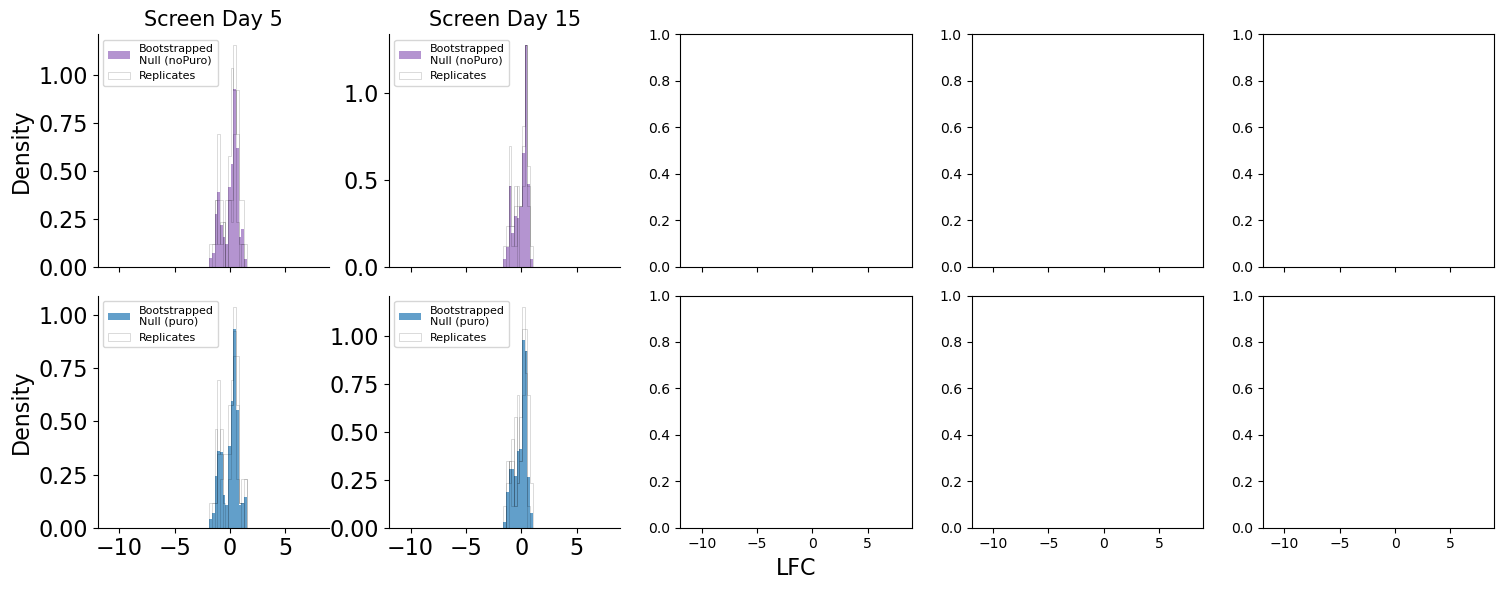

In [34]:
#visualizing the null distributions

fig, ax = plt.subplots(2,5, figsize=(15,6), sharex=True, sharey=False)

conditions = ['d5', 'd15']
name_dict = dict(zip(conditions, ['Screen Day 5', 'Screen Day 15']))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(noPuro_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (noPuro)')
    ax[1][idx].hist(puro_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (puro)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_puro = puro_samp_dict[condition]
    samp_of_interest_noPuro = noPuro_samp_dict[condition]

    for idx2, k in enumerate(samp_of_interest_noPuro):
        if idx2==0:
            ax[0][idx].hist(noPuro_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(noPuro_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_puro):
        if idx2==0:
            ax[1][idx].hist(puro_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(puro_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()

# 1c. Empirical p-value & FDR calculation

In [35]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}'] = adjusted_p_values_low

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for i, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}']
        FDR_high = val[f'FDR_high_{condition_of_interest}']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}'] = min_FDR

    return LFC_df

In [36]:
#first perform computation for noPuro samples

conditions = ['d5', 'd15']

df_holder_noPuro = []
for condition_of_interest in conditions:

    samp_of_interest = noPuro_samp_dict[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, noPuro_LFC_table_w_editing, noPuro_null_dict)

    df_holder_noPuro.append(LFC_df)

combined_LFC_FDR_noPuro = pd.concat(df_holder_noPuro, axis=1)
combined_LFC_FDR_noPuro = combined_LFC_FDR_noPuro.loc[:,~combined_LFC_FDR_noPuro.columns.duplicated()].copy()


In [37]:
#then do the same for puro samples
conditions = ['d5', 'd15']

df_holder_puro = []
for condition_of_interest in conditions:

    samp_of_interest = puro_samp_dict[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, puro_LFC_table_w_editing, puro_null_dict)

    df_holder_puro.append(LFC_df)

combined_LFC_FDR_puro = pd.concat(df_holder_puro, axis=1)
combined_LFC_FDR_puro = combined_LFC_FDR_puro.loc[:,~combined_LFC_FDR_puro.columns.duplicated()].copy()

In [38]:
#save dataframes
combined_LFC_FDR_noPuro.to_csv(OUTDIR /'noPuro_LFC_FDR_df.csv', index=False)
combined_LFC_FDR_puro.to_csv(OUTDIR /'puro_LFC_FDR_df.csv', index=False)

# WOOHOO now can compare editing percentages.

Grace said to plot editing differences with multiple different thresholds and can show how the gap between the puro and non puro conditions grows as the threshold gets more stringent. Base would be 20% threshold but ABE is very efficient so we started increasing the threshold.

Use TARGET_BASE_EDIT_PERC as the point of comparison 

In [45]:
condition = combined_LFC_FDR_noPuro["target_base_edit_perc"] > 80
print(condition.sum())

condition2 = combined_LFC_FDR_puro["target_base_edit_perc"] > 80
print(condition2.sum())

247
318


# NOT DOING THIS STOP HERE 1d. Comparison with MAGeCK results

- Comparing the number & overlap of significant hit calls between MAGeCK (negative binomial parametric model), and our empirical, non-parametric approach
    - Our non-parametric approach is more conservative
    - Goal is to quantify the differences here and perform a sanity check